In [4]:
# # Oasis Infobyte Internship

# ## Level 1 - Task 2

# # Customer Segmentation Analysis using RFM & K-Means Clustering

# **Name:** Jigyasha Jain

# ## Objective

# To segment customers based on purchasing behaviour using RFM Analysis and K-Means Clustering to help businesses design targeted marketing strategies.

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

%matplotlib inline

In [7]:
df = pd.read_csv("online_retail_II.csv.zip")

In [8]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [9]:
df.shape

(1067371, 8)

In [10]:
df.columns

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [12]:
df.describe()

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [13]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [14]:
# ## Initial Inspection

# ### Observations

# - Dataset loaded successfully.
# - Dataset contains customer transactions.
# - Missing values will be handled before analysis.

In [15]:
df.dropna(inplace=True)

In [16]:
df.isnull().sum()

Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
dtype: int64

In [17]:
df = df[~df['Invoice'].astype(str).str.startswith('C')]

In [18]:
df = df[df["Quantity"] > 0]

In [19]:
df = df[df["Price"] > 0]

In [20]:
# ## Data Cleaning

# Cancelled orders, missing values and invalid transactions were removed.

In [21]:
df["TotalAmount"] = df["Quantity"] * df["Price"]

In [22]:
df["TotalAmount"].mean()

np.float64(22.026505126317584)

In [23]:
df.groupby("Customer ID")["Invoice"].nunique().mean()

np.float64(6.289384144266758)

In [24]:
customer_clv = df.groupby("Customer ID")["TotalAmount"].sum()

customer_clv.describe()

count      5878.000000
mean       3018.616737
std       14737.731040
min           2.950000
25%         348.762500
50%         898.915000
75%        2307.090000
max      608821.650000
Name: TotalAmount, dtype: float64

In [26]:
# ## Descriptive Statistics

# Average Purchase Value, Purchase Frequency and Customer Lifetime Value were calculated to understand customer behaviour.

In [27]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [28]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

In [29]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

In [30]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

In [32]:
rfm = df.groupby("Customer ID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "Invoice": "nunique",
    "TotalAmount": "sum"
})

rfm.columns = ["Recency","Frequency","Monetary"]

In [33]:
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,12,77556.46
12347.0,2,8,5633.32
12348.0,75,5,2019.40
12349.0,19,4,4428.69
12350.0,310,1,334.40


In [35]:
# ## Feature Selection

# Three behavioural features were selected:

# - Recency
# - Frequency
# - Monetary Value

# These features best represent customer purchasing behaviour.

In [36]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)


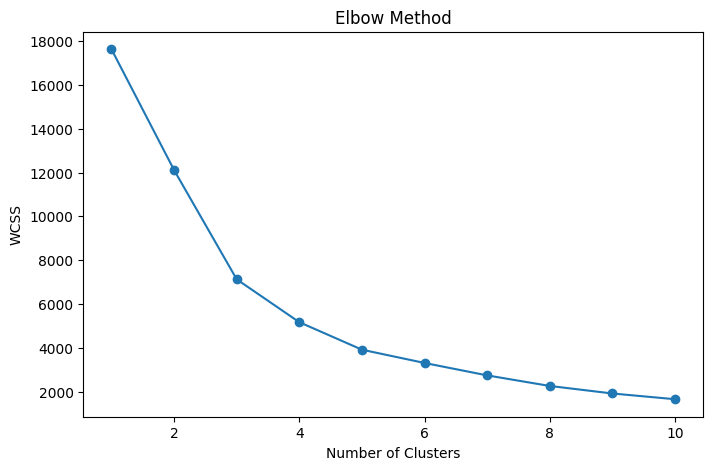

In [37]:
wcss=[]

for i in range(1,11):
    kmeans=KMeans(n_clusters=i,random_state=42,n_init=10)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11),wcss,marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [38]:
kmeans=KMeans(n_clusters=4,random_state=42,n_init=10)

rfm["Cluster"]=kmeans.fit_predict(rfm_scaled)

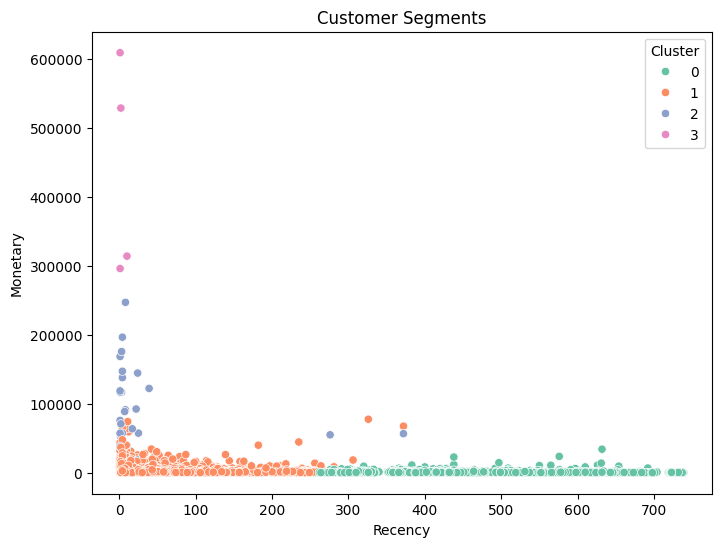

In [39]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x="Recency",
    y="Monetary",
    hue="Cluster",
    palette="Set2"
)

plt.title("Customer Segments")
plt.show()

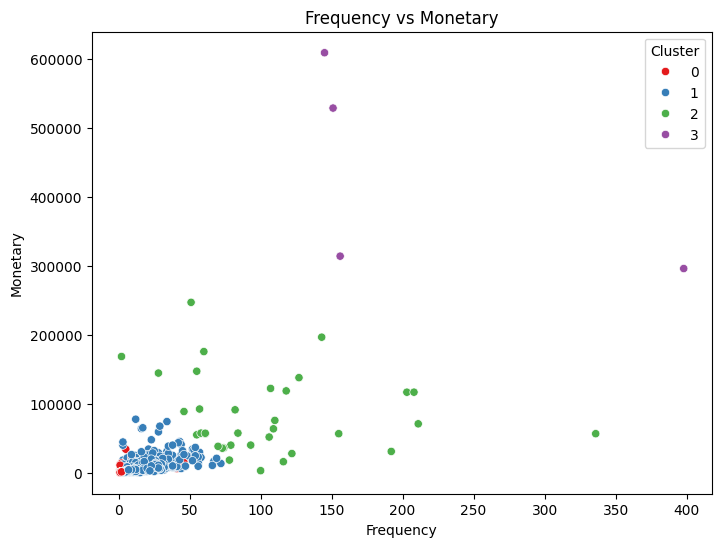

In [40]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="Set1"
)

plt.title("Frequency vs Monetary")
plt.show()

In [41]:
cluster_profile = rfm.groupby("Cluster").mean()

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,463.032032,2.212212,765.244446
1,67.005728,7.307732,3009.402451
2,25.942857,103.714286,83086.079771
3,3.500000,212.500000,436835.792500


In [42]:
# ## Cluster Profile

# Each cluster represents a different customer segment based on Recency, Frequency and Monetary value.

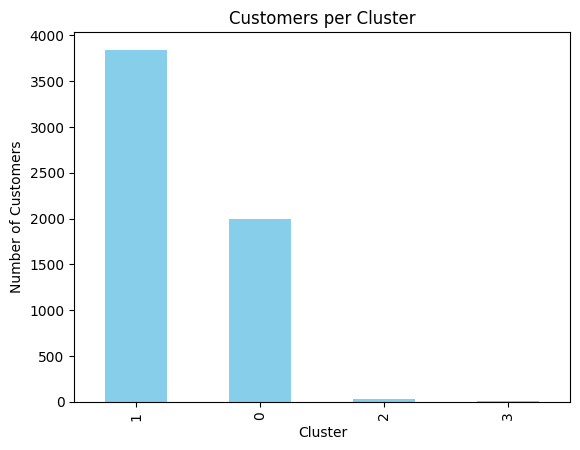

In [43]:
rfm["Cluster"].value_counts().plot(
    kind="bar",
    color="skyblue"
)

plt.title("Customers per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.show()

In [44]:
# # Marketing Recommendations

# ### Cluster 0
# High-value loyal customers.
# Offer loyalty rewards and exclusive benefits.

# ### Cluster 1
# Regular customers.
# Provide personalized product recommendations.

# ### Cluster 2
# At-risk customers.
# Send discount coupons and re-engagement emails.

# ### Cluster 3
# New or low-spending customers.
# Introduce welcome offers and onboarding campaigns.

In [45]:
# # Conclusion

# RFM Analysis and K-Means Clustering successfully segmented customers into meaningful groups based on purchasing behaviour.

# These customer segments can help businesses improve marketing effectiveness, customer retention, and overall profitability through targeted campaigns.